# U-Net Vascular Segmentation Training

segmentation-models-pytorch (smp) を用いた U-Net による血管セグメンテーション。
ResNet34 encoder (ImageNet pretrained) + 4-fold CV。

**前提:** `prepare_data.ipynb` を実行済みで `data/images/`, `data/masks/`, `data/circle_masks/` が存在すること。

In [17]:
# Install segmentation-models-pytorch if not available
try:
    import segmentation_models_pytorch as smp
    print(f'smp version: {smp.__version__}')
except ImportError:
    !pip install segmentation-models-pytorch
    import segmentation_models_pytorch as smp
    print(f'smp installed: {smp.__version__}')

smp version: 0.3.3


In [18]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.model_selection import KFold
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import pandas as pd
from copy import deepcopy
import time

# Paths
DATA_DIR = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project\vascular_segmentation\data')
IMG_DIR = DATA_DIR / 'images'
MASK_DIR = DATA_DIR / 'masks'
CIRCLE_DIR = DATA_DIR / 'circle_masks'
OUTPUT_DIR = DATA_DIR.parent / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# レンズ縁erosion: 評価時にレンズ縁を除外（Frangiと条件統一）
EVAL_ERODE_PX = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Eval circle mask erosion: {EVAL_ERODE_PX}px')

Device: cuda
GPU: Quadro RTX 5000
Eval circle mask erosion: 10px


## 1. Dataset

In [19]:
class VesselDataset(Dataset):
    """Vessel segmentation dataset with albumentations augmentation."""
    
    def __init__(self, image_paths, mask_paths, circle_paths, transform=None, patch_size=None, patches_per_image=1):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.circle_paths = circle_paths
        self.transform = transform
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image
    
    def __len__(self):
        return len(self.image_paths) * self.patches_per_image
    
    def __getitem__(self, idx):
        img_idx = idx // self.patches_per_image
        
        img = cv2.imread(str(self.image_paths[img_idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[img_idx]), cv2.IMREAD_GRAYSCALE)
        circle = cv2.imread(str(self.circle_paths[img_idx]), cv2.IMREAD_GRAYSCALE)
        
        # Normalize mask to [0, 1]
        mask = (mask > 0).astype(np.float32)
        circle = (circle > 0).astype(np.float32)
        
        if self.transform:
            transformed = self.transform(image=img, masks=[mask, circle])
            img = transformed['image']
            mask = transformed['masks'][0]
            circle = transformed['masks'][1]
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1).astype(np.float32) / 255.0)
            mask = torch.from_numpy(mask)
            circle = torch.from_numpy(circle)
        
        return img, mask.unsqueeze(0), circle.unsqueeze(0)

In [20]:
# Augmentation pipelines
def get_train_transform(patch_size=256):
    return A.Compose([
        A.RandomCrop(height=patch_size, width=patch_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.5,
                           border_mode=cv2.BORDER_CONSTANT, value=0),
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.3),
        A.GridDistortion(p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.GaussianBlur(blur_limit=(3, 7), p=0.2),
        A.CLAHE(clip_limit=4.0, p=0.3),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        # Fix negative strides from flip augmentations before tensor conversion
        A.Lambda(image=lambda x, **kw: np.ascontiguousarray(x),
                 mask=lambda x, **kw: np.ascontiguousarray(x)),
        ToTensorV2(),
    ])


def get_val_transform():
    return A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


print('Augmentation pipelines defined')

Augmentation pipelines defined


## 2. Loss Function

In [21]:
class BCEDiceLoss(nn.Module):
    """BCE + Dice combined loss with circle mask support."""
    
    def __init__(self, bce_weight=0.5, dice_weight=0.5, pos_weight=10.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
    
    def dice_loss(self, pred, target, circle_mask, smooth=1.0):
        pred_sig = torch.sigmoid(pred)
        # Apply circle mask
        pred_masked = pred_sig * circle_mask
        target_masked = target * circle_mask
        
        intersection = (pred_masked * target_masked).sum()
        total = pred_masked.sum() + target_masked.sum()
        dice = (2.0 * intersection + smooth) / (total + smooth)
        return 1.0 - dice
    
    def forward(self, pred, target, circle_mask):
        self.bce.pos_weight = self.bce.pos_weight.to(pred.device)
        # BCE on circle-masked regions
        valid = circle_mask > 0
        if valid.sum() == 0:
            return torch.tensor(0.0, device=pred.device)
        bce_loss = self.bce(pred[valid], target[valid])
        dice_loss = self.dice_loss(pred, target, circle_mask)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


print('Loss function defined')

Loss function defined


## 3. Training Functions

In [22]:
def compute_dice(pred_logits, target, circle_mask, threshold=0.5):
    """Compute Dice coefficient for evaluation."""
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    pred_m = pred * circle_mask
    target_m = target * circle_mask
    
    intersection = (pred_m * target_m).sum()
    total = pred_m.sum() + target_m.sum()
    if total == 0:
        return 1.0  # Both empty
    return float((2.0 * intersection) / total)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_dice = 0.0
    n = 0
    
    for imgs, masks, circles in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        circles = circles.to(device)
        
        optimizer.zero_grad()
        pred = model(imgs)
        loss = criterion(pred, masks, circles)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * imgs.size(0)
        total_dice += compute_dice(pred, masks, circles) * imgs.size(0)
        n += imgs.size(0)
    
    return total_loss / n, total_dice / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    n = 0
    
    for imgs, masks, circles in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        circles = circles.to(device)
        
        pred = model(imgs)
        loss = criterion(pred, masks, circles)
        
        total_loss += loss.item() * imgs.size(0)
        total_dice += compute_dice(pred, masks, circles) * imgs.size(0)
        n += imgs.size(0)
    
    return total_loss / n, total_dice / n


print('Training functions defined')

Training functions defined


## 4. 4-Fold Cross Validation

In [23]:
# Collect all file paths
all_stems = sorted([p.stem for p in IMG_DIR.glob('*.png')])
all_img_paths = [IMG_DIR / f'{s}.png' for s in all_stems]
all_mask_paths = [MASK_DIR / f'{s}.png' for s in all_stems]
all_circle_paths = [CIRCLE_DIR / f'{s}.png' for s in all_stems]

print(f'Total images: {len(all_stems)}')

# Training config
N_FOLDS = 4
EPOCHS = 200
BATCH_SIZE = 16
PATCHES_PER_IMAGE = 8
PATCH_SIZE = 256
LR = 1e-4
PATIENCE = 30

print(f'Config: {N_FOLDS}-fold CV, {EPOCHS} epochs, batch={BATCH_SIZE}, patch={PATCH_SIZE}, lr={LR}')

Total images: 22
Config: 4-fold CV, 200 epochs, batch=16, patch=256, lr=0.0001


In [24]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []
fold_histories = []

indices = np.arange(len(all_stems))

for fold, (train_idx, val_idx) in enumerate(kf.split(indices)):
    print(f'\n{"="*60}')
    print(f'Fold {fold+1}/{N_FOLDS}: train={len(train_idx)}, val={len(val_idx)}')
    print(f'Val images: {[all_stems[i][:8] for i in val_idx]}')
    print(f'{"="*60}')
    
    # Datasets
    train_imgs = [all_img_paths[i] for i in train_idx]
    train_masks = [all_mask_paths[i] for i in train_idx]
    train_circles = [all_circle_paths[i] for i in train_idx]
    
    val_imgs = [all_img_paths[i] for i in val_idx]
    val_masks = [all_mask_paths[i] for i in val_idx]
    val_circles = [all_circle_paths[i] for i in val_idx]
    
    train_ds = VesselDataset(
        train_imgs, train_masks, train_circles,
        transform=get_train_transform(PATCH_SIZE),
        patches_per_image=PATCHES_PER_IMAGE
    )
    val_ds = VesselDataset(
        val_imgs, val_masks, val_circles,
        transform=get_val_transform()
    )
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)
    
    # Model
    model = smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation=None
    ).to(device)
    
    criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5, pos_weight=10.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    # Training loop
    best_val_dice = 0.0
    best_model_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
    
    t0 = time.time()
    for epoch in range(EPOCHS):
        train_loss, train_dice = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_dice = validate(model, val_loader, criterion, device)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_model_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 20 == 0 or epoch == 0:
            elapsed = time.time() - t0
            print(f'  Epoch {epoch+1:3d}/{EPOCHS}: '
                  f'train_loss={train_loss:.4f}, train_dice={train_dice:.3f}, '
                  f'val_loss={val_loss:.4f}, val_dice={val_dice:.3f}, '
                  f'best={best_val_dice:.3f}, [{elapsed:.0f}s]')
        
        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1} (patience={PATIENCE})')
            break
    
    elapsed = time.time() - t0
    print(f'  Fold {fold+1} completed in {elapsed:.0f}s, best val Dice: {best_val_dice:.3f}')
    
    # Save best model
    model_path = OUTPUT_DIR / f'unet_fold{fold+1}.pt'
    torch.save(best_model_state, model_path)
    
    fold_results.append({
        'fold': fold + 1,
        'best_val_dice': best_val_dice,
        'best_epoch': np.argmax(history['val_dice']) + 1,
        'val_indices': val_idx.tolist()
    })
    fold_histories.append(history)

print(f'\n{"="*60}')
print('4-Fold CV Complete')
for r in fold_results:
    print(f'  Fold {r["fold"]}: best_dice={r["best_val_dice"]:.3f} (epoch {r["best_epoch"]})')
mean_dice = np.mean([r['best_val_dice'] for r in fold_results])
print(f'  Mean Dice: {mean_dice:.3f}')


Fold 1/4: train=16, val=6
Val images: ['0E900037', '1C329021', '366E2260', '6B193D74', '83FA07F4', '94D75FAA']


C:\Users\ykita\AppData\Local\Temp\ipykernel_573520\921942380.py:18: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or partial().
  A.Lambda(image=lambda x, **kw: np.ascontiguousarray(x),


  Epoch   1/200: train_loss=1.0264, train_dice=0.140, val_loss=0.9339, val_dice=0.118, best=0.118, [4s]
  Epoch  20/200: train_loss=0.5818, train_dice=0.506, val_loss=0.5802, val_dice=0.466, best=0.467, [68s]
  Epoch  40/200: train_loss=0.4942, train_dice=0.577, val_loss=0.4973, val_dice=0.496, best=0.541, [135s]
  Epoch  60/200: train_loss=0.4433, train_dice=0.619, val_loss=0.4494, val_dice=0.572, best=0.585, [202s]
  Epoch  80/200: train_loss=0.4234, train_dice=0.634, val_loss=0.4229, val_dice=0.595, best=0.599, [269s]
  Epoch 100/200: train_loss=0.3937, train_dice=0.637, val_loss=0.4260, val_dice=0.603, best=0.608, [338s]
  Epoch 120/200: train_loss=0.4012, train_dice=0.633, val_loss=0.4121, val_dice=0.606, best=0.611, [403s]
  Epoch 140/200: train_loss=0.3698, train_dice=0.665, val_loss=0.4232, val_dice=0.603, best=0.611, [468s]
  Early stopping at epoch 143 (patience=30)
  Fold 1 completed in 477s, best val Dice: 0.611

Fold 2/4: train=16, val=6
Val images: ['286D9676', '30A0F797'

## 5. Training Curves

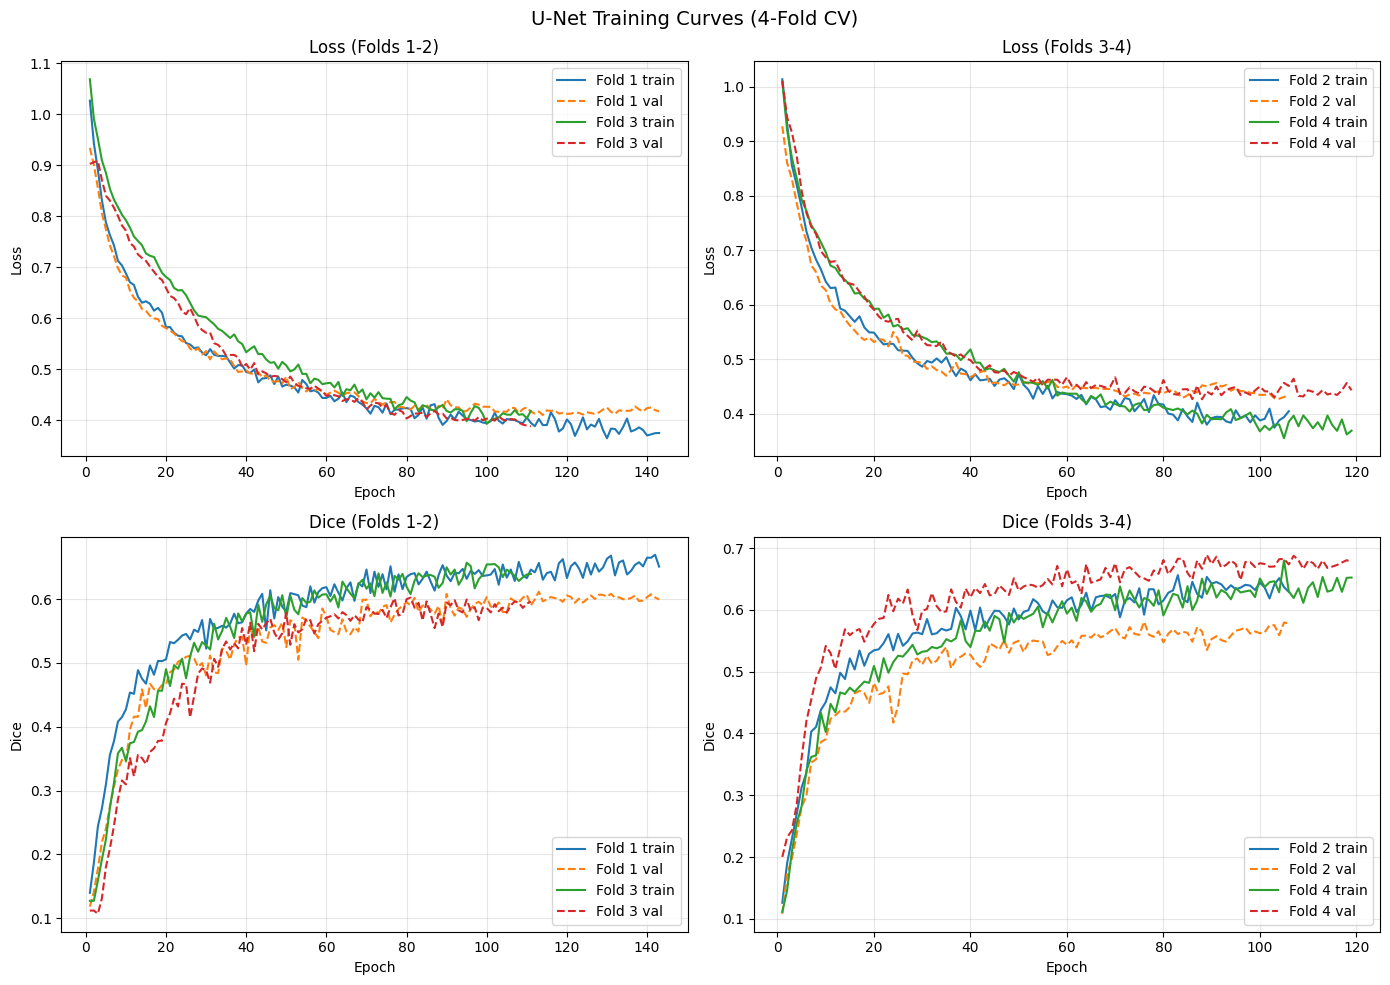

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for fold_idx, hist in enumerate(fold_histories):
    ax_loss = axes[0, 0] if fold_idx < 2 else axes[0, 1]
    ax_dice = axes[1, 0] if fold_idx < 2 else axes[1, 1]
    
    epochs = range(1, len(hist['train_loss']) + 1)
    
    axes[0, fold_idx % 2].plot(epochs, hist['train_loss'], label=f'Fold {fold_idx+1} train')
    axes[0, fold_idx % 2].plot(epochs, hist['val_loss'], '--', label=f'Fold {fold_idx+1} val')
    axes[1, fold_idx % 2].plot(epochs, hist['train_dice'], label=f'Fold {fold_idx+1} train')
    axes[1, fold_idx % 2].plot(epochs, hist['val_dice'], '--', label=f'Fold {fold_idx+1} val')

for i in range(2):
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'Loss (Folds {2*i+1}-{2*i+2})')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Dice')
    axes[1, i].set_title(f'Dice (Folds {2*i+1}-{2*i+2})')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('U-Net Training Curves (4-Fold CV)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Per-Image Evaluation

各foldのbest modelで対応するvalidation画像を推論し、per-imageメトリクスを計算

In [26]:
def compute_full_metrics(pred_binary, gt_binary, circle_mask):
    """circle_mask内でDice, IoU, Sensitivity, Specificity, Precisionを計算。"""
    valid = circle_mask > 0
    p = pred_binary[valid] > 0
    g = gt_binary[valid] > 0
    
    tp = int(np.sum(p & g))
    fp = int(np.sum(p & ~g))
    fn = int(np.sum(~p & g))
    tn = int(np.sum(~p & ~g))
    
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    return {'dice': dice, 'iou': iou, 'sensitivity': sens, 'specificity': spec, 'precision': prec}


@torch.no_grad()
def predict_image(model, img_path, device):
    """Single image prediction at 512x512."""
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    transform = get_val_transform()
    transformed = transform(image=img_rgb)
    img_tensor = transformed['image'].unsqueeze(0).to(device)
    
    model.eval()
    logits = model(img_tensor)
    pred = (torch.sigmoid(logits) > 0.5).squeeze().cpu().numpy().astype(np.uint8)
    return pred


# Evaluate all images using their respective fold models
# 評価時はeroded circle maskを使用（レンズ縁除外、Frangiと条件統一）
per_image_results = []
all_predictions = {}  # stem -> pred_mask
erode_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * EVAL_ERODE_PX + 1, 2 * EVAL_ERODE_PX + 1))

for fold_info in fold_results:
    fold = fold_info['fold']
    val_idx = fold_info['val_indices']
    
    # Load best model for this fold
    model = smp.Unet(
        encoder_name='resnet34',
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None
    ).to(device)
    model.load_state_dict(torch.load(OUTPUT_DIR / f'unet_fold{fold}.pt', map_location=device))
    
    for i in val_idx:
        stem = all_stems[i]
        pred = predict_image(model, all_img_paths[i], device)
        
        gt = cv2.imread(str(all_mask_paths[i]), cv2.IMREAD_GRAYSCALE)
        circle = cv2.imread(str(all_circle_paths[i]), cv2.IMREAD_GRAYSCALE)
        circle_eroded = cv2.erode(circle, erode_kernel, iterations=1)
        
        # Apply eroded circle mask to prediction
        pred[circle_eroded == 0] = 0
        
        metrics = compute_full_metrics(pred * 255, gt, circle_eroded)
        metrics['filename'] = stem
        metrics['fold'] = fold
        per_image_results.append(metrics)
        all_predictions[stem] = pred

df_unet = pd.DataFrame(per_image_results)
print('=== U-Net Per-Image Metrics (eroded circle mask) ===')
print(df_unet[['filename', 'fold', 'dice', 'iou', 'sensitivity', 'precision']].to_string(index=False))
print()
print('=== U-Net Mean Metrics ===')
for col in ['dice', 'iou', 'sensitivity', 'specificity', 'precision']:
    print(f'  {col:>12s}: {df_unet[col].mean():.3f} +/- {df_unet[col].std():.3f}')

C:\Users\ykita\AppData\Local\Temp\ipykernel_573520\1846933074.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(OUTPUT_DIR / f'unet_fold{

=== U-Net Per-Image Metrics (eroded circle mask) ===
                            filename  fold     dice      iou  sensitivity  precision
0E900037-CE07-405C-82A4-5293EB2FC8F4     1 0.636730 0.467060     0.781673   0.537131
1C329021-715D-46B5-97AF-864952A86DF7     1 0.515030 0.346829     0.849970   0.369446
366E2260-EAA3-4CB5-BA99-690D5CDA75B2     1 0.694386 0.531846     0.843763   0.589944
6B193D74-82AE-4FAC-9DB2-D6DA4DBB56A6     1 0.686048 0.522126     0.802120   0.599323
83FA07F4-7781-4AFA-A51F-1A095E254CE7     1 0.678279 0.513178     0.885641   0.549597
94D75FAA-8AD0-4834-B089-16C71A57E182     1 0.483524 0.318847     0.571667   0.418931
286D9676-12C2-4026-A53D-73BD94502021     2 0.624092 0.453586     0.798040   0.512404
30A0F797-DEFD-4137-A11A-7E3529A7E0D4     2 0.185472 0.102215     0.225244   0.157638
7BA9B019-0851-427D-868A-EC84E1FC1C4C     2 0.729728 0.574465     0.868109   0.629398
7E4ADD96-1DFC-4B0D-84B8-F0A438327284     2 0.747386 0.596662     0.888583   0.644910
9CA1796B-38A

## 7. Comparison with Frangi Baseline

In [27]:
# Load Frangi results
frangi_csv = DATA_DIR.parent / 'frangi_results.csv'
if frangi_csv.exists():
    df_frangi = pd.read_csv(frangi_csv)
    
    print('=== Method Comparison ===')
    print(f'{"Metric":>12s} | {"Frangi":>10s} | {"U-Net":>10s} | {"Delta":>8s}')
    print('-' * 50)
    for col in ['dice', 'iou', 'sensitivity', 'specificity', 'precision']:
        f_val = df_frangi[col].mean()
        u_val = df_unet[col].mean()
        delta = u_val - f_val
        sign = '+' if delta >= 0 else ''
        print(f'{col:>12s} | {f_val:>10.3f} | {u_val:>10.3f} | {sign}{delta:>7.3f}')
else:
    print('Frangi results not found. Run frangi_baseline.ipynb first.')

=== Method Comparison ===
      Metric |     Frangi |      U-Net |    Delta
--------------------------------------------------
        dice |      0.337 |      0.621 | +  0.284
         iou |      0.218 |      0.461 | +  0.243
 sensitivity |      0.398 |      0.790 | +  0.392
 specificity |      0.946 |      0.956 | +  0.010
   precision |      0.314 |      0.518 | +  0.204


## 8. Prediction Visualization

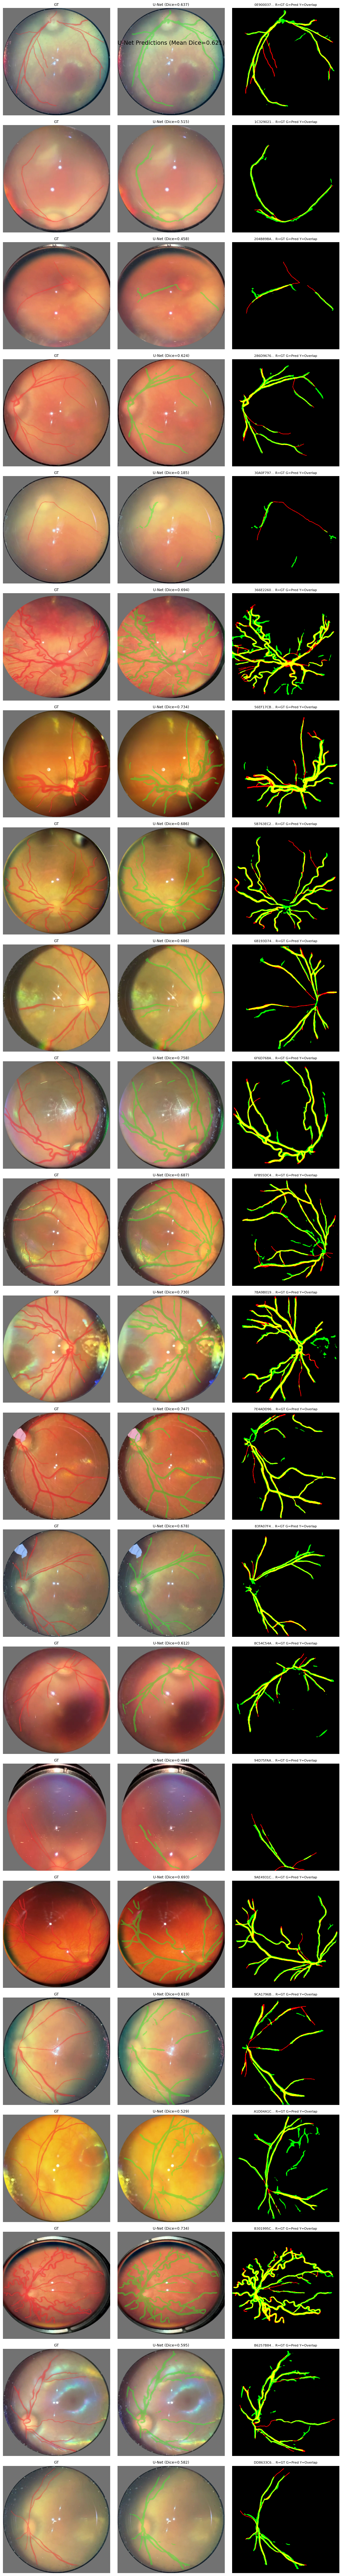

In [28]:
n = len(all_predictions)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = axes[np.newaxis, :]

for idx, stem in enumerate(sorted(all_predictions.keys())):
    img = cv2.imread(str(IMG_DIR / f'{stem}.png'))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt = cv2.imread(str(MASK_DIR / f'{stem}.png'), cv2.IMREAD_GRAYSCALE)
    pred = all_predictions[stem] * 255
    
    # GT overlay
    overlay_gt = img_rgb.copy()
    overlay_gt[gt > 0] = [255, 50, 50]
    blended_gt = cv2.addWeighted(img_rgb, 0.6, overlay_gt, 0.4, 0)
    axes[idx, 0].imshow(blended_gt)
    axes[idx, 0].set_title('GT', fontsize=9)
    axes[idx, 0].axis('off')
    
    # Prediction overlay
    overlay_pred = img_rgb.copy()
    overlay_pred[pred > 0] = [50, 255, 50]
    blended_pred = cv2.addWeighted(img_rgb, 0.6, overlay_pred, 0.4, 0)
    row_data = df_unet[df_unet['filename'] == stem]
    dice_val = row_data['dice'].values[0] if len(row_data) > 0 else 0
    axes[idx, 1].imshow(blended_pred)
    axes[idx, 1].set_title(f'U-Net (Dice={dice_val:.3f})', fontsize=9)
    axes[idx, 1].axis('off')
    
    # Side-by-side masks
    combined = np.zeros((*gt.shape, 3), dtype=np.uint8)
    combined[:, :, 0] = gt  # Red = GT
    combined[:, :, 1] = pred  # Green = Pred
    # Yellow = overlap
    axes[idx, 2].imshow(combined)
    axes[idx, 2].set_title(f'{stem[:8]}... R=GT G=Pred Y=Overlap', fontsize=8)
    axes[idx, 2].axis('off')

plt.suptitle(f'U-Net Predictions (Mean Dice={df_unet["dice"].mean():.3f})', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# Save U-Net results
df_unet.to_csv(DATA_DIR.parent / 'unet_results.csv', index=False)
print(f'U-Net results saved to {DATA_DIR.parent / "unet_results.csv"}')

print(f'\n=== Final Summary ===')
print(f'U-Net Mean Dice: {df_unet["dice"].mean():.3f}')
print(f'U-Net Mean IoU:  {df_unet["iou"].mean():.3f}')
if frangi_csv.exists():
    print(f'Frangi Mean Dice: {df_frangi["dice"].mean():.3f}')
    print(f'Improvement: +{df_unet["dice"].mean() - df_frangi["dice"].mean():.3f} Dice')

U-Net results saved to C:\Users\ykita\ROP_AI_project\ROP_project\vascular_segmentation\unet_results.csv

=== Final Summary ===
U-Net Mean Dice: 0.621
U-Net Mean IoU:  0.461
Frangi Mean Dice: 0.337
Improvement: +0.284 Dice
